### Get heatmap plots for figure 1 and 4

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.gridspec as gridspec

model_type = "ResNet" # "ResNet" = "DenseNet"
cutoff_mode = "99th" # "95th", "99th", "90th", "no_cutoff"

dilation_iter_idps = 2
dilation_iter_brain_age = 0
dilation_iter_lesions = 0

if model_type == "ResNet":
    df_cidps = pd.read_pickle(f"/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/results/data_frames/warped_atlas/exclusive_nodes/idps/rma_df_dil_{dilation_iter_idps}_{cutoff_mode}.pkl")
    df_lesions = pd.read_pickle(f"/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/results/data_frames/warped_atlas/lesions/rma_df_lesions_dil_iter_{dilation_iter_lesions}_{cutoff_mode}.pkl")
    df_brain_age_ranking = pd.read_pickle(f"/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/results/data_frames/warped_atlas/exclusive_nodes/brain_age_ranking/single_participant_level_percentile_{dilation_iter_brain_age}_{cutoff_mode}.pkl")

elif model_type == "DenseNet":
    df_cidps = pd.read_pickle(f"/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/results/data_frames/densenet/cidps/rma_df_dil_{dilation_iter_idps}_{cutoff_mode}_w_full_dummydis.pkl")
    df_lesions = pd.read_pickle(f"/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/results/data_frames/densenet/lesions/rma_df_lesions_dil_iter_{dilation_iter_lesions}_{cutoff_mode}.pkl")
    df_brain_age_ranking = pd.read_pickle(f"/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/results/data_frames/densenet/brain_age/single_participant_level_percentile_{dilation_iter_brain_age}_{cutoff_mode}.pkl")

In [41]:
# extract brain age overlap scores from precomputed dataframe and transpose into the correct format
df_brain_age_ranking_ = df_brain_age_ranking[['xai_m', 'overlap']].T

df_brain_age_ranking_.columns = df_brain_age_ranking_.iloc[0]

df_brain_age_ranking_ = df_brain_age_ranking_.drop(["xai_m"])

df_brain_age_ranking_

xai_m,LRP_EpsilonPlusFlat,LRP_EpsilonPlus,LRP_EpsilonAlpha2Beta1,LRP_EpsilonAlpha2Beta1Flat,SmoothGrad,ExcitationBackprop,DeepLift,DeepLift_mean_img,GuidedBackprop,GuidedGradCam,GradCAM,GradCAM_l1,GradCAM_l2,GradCAM_l3,InputXGradient
overlap,0.550107,0.523406,0.553286,0.550157,0.527689,0.510005,0.55971,0.586094,0.327712,0.328565,0.324332,0.326608,0.29733,0.364084,0.594108


In [ ]:
# extract rma scores from precomputed df and pivot to have XAI methods as columns, and tasks as row indices
df_cidps = df_cidps.pivot(index='task', columns='xai_m', values='score')

# simplify row names
new_index = []
for idx in df_cidps.index:
    new_idx = idx.replace(' (left hemisphere)', '')
    new_idx = new_idx.replace(' (right hemisphere)', '')
    new_idx = new_idx.replace(' (whole brain)', '')
    new_idx = new_idx.replace('\n', ' ')
    new_idx = new_idx.replace('high Area of G-rectus and low Area of G-rectus', 'high Area of G-rectus and low Volume of Caudate')
    new_idx = new_idx.replace('high Mean thickness of G-postcentral and low Mean thickness of G-postcentral', 'high Mean thickness of G-postcentral and low Volume of Hippocampus')

    new_index.append(new_idx)

df_cidps.index = new_index

df_cidps


xai_m,DeepLift,DeepLift_mean_img,ExcitationBackprop,GradCAM,GradCAM_l1,GradCAM_l2,GradCAM_l3,GuidedBackprop,GuidedGradCam,InputXGradient,LRP_EpsilonAlpha2Beta1,LRP_EpsilonAlpha2Beta1Flat,LRP_EpsilonPlus,LRP_EpsilonPlusFlat,SmoothGrad
Area of G-orbital,0.129479,0.256857,0.181777,0.050487,0.014865,0.025878,0.024232,0.173178,0.166481,0.247184,0.218532,0.206907,0.202193,0.197222,0.282035
Area of G-rectus,0.150815,0.234868,0.238435,0.041217,0.004320,0.008923,0.023718,0.206540,0.104039,0.215924,0.279053,0.261441,0.243460,0.237763,0.277509
Mean intensity of Pallidum,0.335762,0.258931,0.116022,0.050835,0.013572,0.027465,0.072575,0.170508,0.272524,0.333292,0.176072,0.187718,0.112804,0.117232,0.331639
Mean intensity of Putamen,0.366115,0.328048,0.208824,0.084512,0.006022,0.033899,0.006394,0.172930,0.251489,0.415017,0.204702,0.222051,0.193106,0.201705,0.433219
Mean thickness of G-insular-short,0.138998,0.163697,0.040784,0.000419,0.002637,0.005695,0.001567,0.020570,0.011002,0.176665,0.042989,0.051165,0.036003,0.039514,0.191085
Mean thickness of G-postcentral,0.207818,0.282630,0.107910,0.008197,0.014412,0.011702,0.001368,0.086270,0.060586,0.230757,0.155759,0.155893,0.120647,0.122799,0.254340
Volume of Brain-Stem,0.337661,0.421088,0.555872,0.059828,0.051319,0.110826,0.122664,0.461851,0.220588,0.358048,0.461975,0.428030,0.438042,0.422623,0.374056
Volume of Caudate,0.265244,0.266023,0.152908,0.067696,0.016449,0.018474,0.010002,0.100628,0.137402,0.303384,0.169806,0.164476,0.129869,0.125903,0.315955
Volume of Hippocampus,0.309675,0.349893,0.168211,0.146743,0.016360,0.009369,0.051927,0.193501,0.235041,0.333517,0.183800,0.191282,0.160249,0.168511,0.382499
Volume of Lateral-Ventricle,0.155762,0.130631,0.124624,0.049472,0.090317,0.146006,0.070506,0.127725,0.094608,0.190312,0.190463,0.193053,0.192814,0.212984,0.280530


In [43]:
# extract rma scores for lesions
df_lesions = df_lesions.pivot(index='task', columns='xai_m', values='score')
df_lesions


xai_m,DeepLift,DeepLift_mean_img,ExcitationBackprop,GradCAM,GradCAM_l1,GradCAM_l2,GradCAM_l3,GuidedBackprop,GuidedGradCam,InputXGradient,LRP_EpsilonAlpha2Beta1,LRP_EpsilonAlpha2Beta1Flat,LRP_EpsilonPlus,LRP_EpsilonPlusFlat,SmoothGrad
task,,,,,,,,,,,,,,,
pv_lesion_load,0.131634,0.093853,0.051867,0.019673,0.032321,0.051481,0.021281,0.039305,0.047868,0.1728,0.096318,0.082102,0.103741,0.090369,0.178188


In [44]:
# combine results from each stage into single df
combined_df = pd.concat([df_cidps, df_lesions, df_brain_age_ranking_])

# fix dtypes
s = combined_df.select_dtypes(include='object').columns
combined_df[s] = combined_df[s].astype("float")

combined_df.index.names = ['task']

# change row order
combined_df = combined_df.reindex(index = ['Mean intensity of Pallidum','Mean intensity of Putamen',
                                           'Volume of Caudate','Volume of Hippocampus',
                                           'Mean thickness of G-insular-short','Mean thickness of G-postcentral',
                                           'Area of G-orbital', 'Area of G-rectus',
                                           'Volume of Brain-Stem','Volume of Lateral-Ventricle',
                                           'high Area of G-rectus and low Volume of Caudate','high Mean thickness of G-postcentral and low Volume of Hippocampus',
                                           'pv_lesion_load',
                                           'overlap',
                                           ])

# fix task names
combined_df = combined_df.rename(index={"overlap": "aging marker overlap", "pv_lesion_load": "lesion load"})

# grouped tasks:
custom_rows = {"Subcortical Intensities": ['Mean intensity of Pallidum', 'Mean intensity of Putamen'],
               "Subcortical Volumes": ['Volume of Caudate', 'Volume of Hippocampus'],
               "Cortical Thicknesses": ['Mean thickness of G-insular-short', 'Mean thickness of G-postcentral'],
               "Cortical Areas": ['Area of G-orbital', 'Area of G-rectus'],
               "Artificial Diseases": ['high Area of G-rectus and low Volume of Caudate', 'high Mean thickness of G-postcentral and low Volume of Hippocampus'],
               "small targets": ['Mean intensity of Pallidum', 'Volume of Caudate', 'Mean thickness of G-insular-short', 'Area of G-rectus'],
               "large targets": ['Mean intensity of Putamen', 'Volume of Hippocampus', 'Mean thickness of G-postcentral', 'Area of G-orbital'],
               "low_accuracy": ['Volume of Hippocampus', 'Mean thickness of G-insular-short', 'Volume of Lateral-Ventricle', 'high Mean thickness of G-postcentral and low Volume of Hippocampus'],
               "high_accuracy": ['Volume of Caudate', 'Mean thickness of G-postcentral', 'Area of G-orbital', 'Volume of Brain-Stem', 'high Area of G-rectus and low Volume of Caudate'],
               "distributed_targets": ["high Area of G-rectus and low Volume of Caudate", "high Mean thickness of G-postcentral and low Volume of Hippocampus", "lesion load"],
               }

# add gouped tasks to large df:
for row_name in custom_rows:
    fields = custom_rows[row_name]
    sub_df = combined_df.loc[fields]
    sub_df_means = sub_df.mean()
    sub_df_means.name = row_name
    combined_df = pd.concat([combined_df, pd.DataFrame([sub_df_means])])

# reorder xai methods
if model_type == "ResNet":
    combined_df_save = combined_df[["LRP_EpsilonAlpha2Beta1", "LRP_EpsilonAlpha2Beta1Flat", "LRP_EpsilonPlus", "LRP_EpsilonPlusFlat", "ExcitationBackprop",  "GuidedBackprop", "GuidedGradCam", "GradCAM_l1", "GradCAM_l2", "GradCAM_l3", "GradCAM", "InputXGradient", "DeepLift_mean_img", "SmoothGrad"]]

elif model_type == "DENSENET":
    combined_df_save = combined_df[["LRP_EpsilonAlpha2Beta1", "LRP_EpsilonAlpha2Beta1Flat", "LRP_EpsilonPlus", "LRP_EpsilonPlusFlat", "ExcitationBackprop",  "GuidedBackprop", "GuidedGradCam", "GradCAM_l3", "GradCAM", "InputXGradient", "DeepLift_mean_img", "SmoothGrad"]]

# simplify deep lift name
combined_df_save = combined_df_save.rename(columns={'DeepLift_mean_img': 'DeepLift'})

# save with full XAI methods
combined_df_save.to_csv(f'/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/scripts_xai_related/generate_paper_output/tables/RMA_FULL_TABLE_{model_type}.csv')

# remove lower layer GradCAM variants for main plot
combined_df = combined_df[["LRP_EpsilonAlpha2Beta1", "LRP_EpsilonAlpha2Beta1Flat", "LRP_EpsilonPlus", "LRP_EpsilonPlusFlat", "ExcitationBackprop",  "GuidedBackprop", "GuidedGradCam", "GradCAM_l3", "GradCAM", "InputXGradient", "DeepLift_mean_img", "SmoothGrad"]]

display(combined_df.style.background_gradient(axis=1))

# save full results tables
combined_df.to_pickle(f"/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/results/data_frames/th_comparison/combined_df_{cutoff_mode}_{model_type}.pkl")

xai_m,LRP_EpsilonAlpha2Beta1,LRP_EpsilonAlpha2Beta1Flat,LRP_EpsilonPlus,LRP_EpsilonPlusFlat,ExcitationBackprop,GuidedBackprop,GuidedGradCam,GradCAM_l3,GradCAM,InputXGradient,DeepLift_mean_img,SmoothGrad
Mean intensity of Pallidum,0.176072,0.187718,0.112804,0.117232,0.116022,0.170508,0.272524,0.072575,0.050835,0.333292,0.258931,0.331639
Mean intensity of Putamen,0.204702,0.222051,0.193106,0.201705,0.208824,0.172930,0.251489,0.006394,0.084512,0.415017,0.328048,0.433219
Volume of Caudate,0.169806,0.164476,0.129869,0.125903,0.152908,0.100628,0.137402,0.010002,0.067696,0.303384,0.266023,0.315955
Volume of Hippocampus,0.183800,0.191282,0.160249,0.168511,0.168211,0.193501,0.235041,0.051927,0.146743,0.333517,0.349893,0.382499
Mean thickness of G-insular-short,0.042989,0.051165,0.036003,0.039514,0.040784,0.020570,0.011002,0.001567,0.000419,0.176665,0.163697,0.191085
Mean thickness of G-postcentral,0.155759,0.155893,0.120647,0.122799,0.107910,0.086270,0.060586,0.001368,0.008197,0.230757,0.282630,0.254340
Area of G-orbital,0.218532,0.206907,0.202193,0.197222,0.181777,0.173178,0.166481,0.024232,0.050487,0.247184,0.256857,0.282035
Area of G-rectus,0.279053,0.261441,0.243460,0.237763,0.238435,0.206540,0.104039,0.023718,0.041217,0.215924,0.234868,0.277509
Volume of Brain-Stem,0.461975,0.428030,0.438042,0.422623,0.555872,0.461851,0.220588,0.122664,0.059828,0.358048,0.421088,0.374056
Volume of Lateral-Ventricle,0.190463,0.193053,0.192814,0.212984,0.124624,0.127725,0.094608,0.070506,0.049472,0.190312,0.130631,0.280530


In [45]:
# Row names and order for heatmap plots presented in Fig. 1 and Fig 4.
custom_rows = {"Subcortical Intensities": ["Subcortical Intensities"],
               "Subcortical Volumes": ["Subcortical Volumes"],
               "Cortical Thicknesses": ["Cortical Thicknesses"],
               "Cortical Areas": ["Cortical Areas"],
               "High Contrast Targets": ['Volume of Brain-Stem', 'Volume of Lateral-Ventricle'],
               "Small Targets": ['small targets'],
               "Large Targets": ['large targets'],
               "Distributed Targets": ['distributed_targets'],
               "Low Accuracy": ["low_accuracy"],
               "High Accuracy": ["high_accuracy"],
               "Artificial Diseases": ["Artificial Diseases"],
               "WM-Lesions" : ['lesion load'],
               "Aging Markers": ['aging marker overlap'],
               }


plot_df = pd.DataFrame()

for i, row_name in enumerate(custom_rows):
    fields = custom_rows[row_name]

    sub_df = combined_df.loc[fields]

    sub_df_means = sub_df.mean()
    sub_df_means.name = row_name

    plot_df = pd.concat([plot_df, pd.DataFrame([sub_df_means])])

plot_df = plot_df.rename(columns={'DeepLift_mean_img': 'DeepLift', 'GradCAM_l3': 'GradCAM (higher resolution)'})

# display(plot_df.style.background_gradient(axis=1))
display(plot_df.style.background_gradient(axis=1))


xai_m,LRP_EpsilonAlpha2Beta1,LRP_EpsilonAlpha2Beta1Flat,LRP_EpsilonPlus,LRP_EpsilonPlusFlat,ExcitationBackprop,GuidedBackprop,GuidedGradCam,GradCAM (higher resolution),GradCAM,InputXGradient,DeepLift,SmoothGrad
Subcortical Intensities,0.190387,0.204885,0.152955,0.159469,0.162423,0.171719,0.262006,0.039484,0.067674,0.374154,0.293490,0.382429
Subcortical Volumes,0.176803,0.177879,0.145059,0.147207,0.160559,0.147065,0.186222,0.030965,0.107220,0.318451,0.307958,0.349227
Cortical Thicknesses,0.099374,0.103529,0.078325,0.081156,0.074347,0.053420,0.035794,0.001467,0.004308,0.203711,0.223164,0.222712
Cortical Areas,0.248792,0.234174,0.222826,0.217492,0.210106,0.189859,0.135260,0.023975,0.045852,0.231554,0.245863,0.279772
High Contrast Targets,0.326219,0.310542,0.315428,0.317804,0.340248,0.294788,0.157598,0.096585,0.054650,0.274180,0.275859,0.327293
Small Targets,0.166980,0.166200,0.130534,0.130103,0.137037,0.124562,0.131242,0.026965,0.040042,0.257316,0.230880,0.279047
Large Targets,0.190698,0.194034,0.169049,0.172559,0.166680,0.156470,0.178399,0.020980,0.072485,0.306619,0.304357,0.338023
Distributed Targets,0.131287,0.124836,0.126514,0.124126,0.092348,0.098913,0.068699,0.036844,0.022839,0.206968,0.217739,0.230595
Low Accuracy,0.133688,0.137566,0.126997,0.135916,0.102336,0.107586,0.107293,0.041498,0.059735,0.236720,0.237615,0.283631
High Accuracy,0.237223,0.226590,0.209526,0.205580,0.229584,0.198162,0.130953,0.041105,0.038550,0.268218,0.295945,0.291914


In [46]:
# scale scores row-wise to highlight xai method differences rather than task differences
plot_df.to_csv('/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/scripts_xai_related/generate_paper_output/tables/RMA_TABLE_no_scale.csv')

# min-max scaling
plot_df_ = (plot_df - plot_df.min(axis=1).values[:, None]) / (plot_df.max(axis=1).values[:, None] - plot_df.min(axis=1).values[:, None])
plot_df_.to_csv(f'/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/scripts_xai_related/generate_paper_output/tables/RMA_TABLE_MIN-MAX_{model_type}.csv')

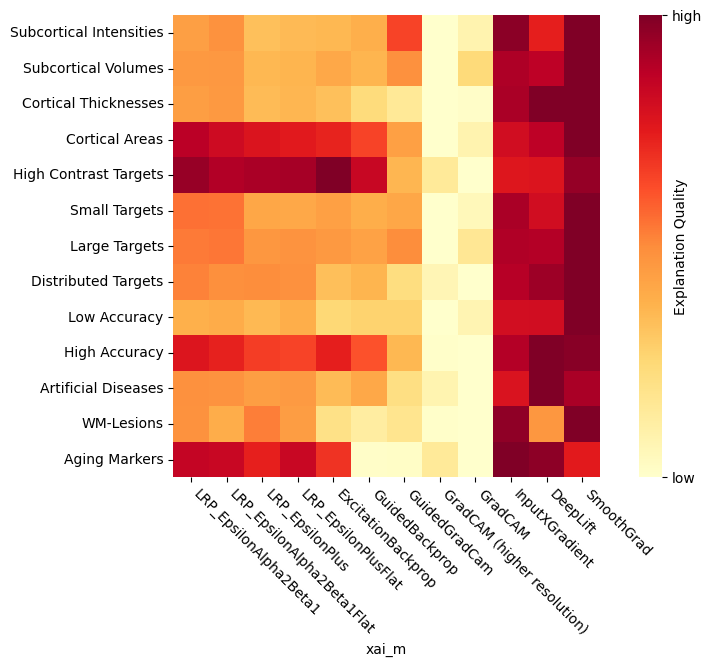

In [47]:
# plot heatmap
fig = plt.figure(figsize=(10, 6))

ax = sns.heatmap(plot_df_, cmap="YlOrRd", fmt=".2f",square=True, cbar_kws={}) 

# get the colorbar and set custom tick labels
colorbar = ax.collections[0].colorbar
vmin, vmax = colorbar.vmin, colorbar.vmax

# set tick positions at min and max
colorbar.set_ticks([vmin, vmax])

plt.xticks(rotation=-45, ha='left')
colorbar.set_ticklabels(['low', 'high'])

colorbar.set_label('Explanation Quality', labelpad=-20)

# show the heatmap
plt.show()

# save figure
fig.savefig("/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/scripts_xai_related/generate_paper_output/plots/heatmap_brain.png", dpi=500, bbox_inches='tight', pad_inches=0)




### Natural image comparison

In [48]:
# brain age overlap is not computed using rma, hence drop
plot_df_ = plot_df_.drop("Aging Markers", axis=0)

In [49]:
# load imagenet resutls
inet_df  = pd.read_pickle('/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/results/data_frames/image_net_xai/imagenet_xai.pkl')

# w.o. GradCAM layer 1 und 2:
inet_df = inet_df[["LRP_EpsilonAlpha2Beta1", "LRP_EpsilonAlpha2Beta1Flat", "LRP_EpsilonPlus", "LRP_EpsilonPlusFlat", "ExcitationBackprop",  "GuidedBackprop", "GuidedGradCam", "GradCAM_l3", "GradCAM", "InputXGradient", "DeepLift", "SmoothGrad"]]

# simplify naming
inet_df = inet_df.rename(columns={'GradCAM_l3': 'GradCAM (higher resolution)'})

# imagenet category supercategories
tasks = ["Animals", "Plants", "Artificial Structures", "Clothing and Accessories", "Beverages and Food", "Furniture", "Sports and Equipment", "Vehicles", "Machines", "Tools and Implements", "Electrical Devices", "Instruments"]
inet_df = inet_df[inet_df.index.isin(tasks)]

inet_df.to_csv('/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/scripts_xai_related/generate_paper_output/tables/RMA_IMAGE_NET.csv')

# min max scale - matching brain results
inet_df_ = (inet_df - inet_df.min(axis=1).values[:, None]) / (inet_df.max(axis=1).values[:, None] - inet_df.min(axis=1).values[:, None])

inet_df_

xai_m,LRP_EpsilonAlpha2Beta1,LRP_EpsilonAlpha2Beta1Flat,LRP_EpsilonPlus,LRP_EpsilonPlusFlat,ExcitationBackprop,GuidedBackprop,GuidedGradCam,GradCAM (higher resolution),GradCAM,InputXGradient,DeepLift,SmoothGrad
task,,,,,,,,,,,,
Animals,0.850617,0.944069,0.962463,1.000000,0.885240,0.816608,0.948752,0.000000,0.834824,0.223444,0.210424,0.681936
Plants,0.770456,0.838985,0.841562,0.919945,0.691118,0.457229,0.791808,0.230396,1.000000,0.000000,0.100067,0.459299
Artificial Structures,0.832392,0.873732,0.913538,0.918543,0.806184,0.722073,1.000000,0.288158,0.975772,0.000000,0.042676,0.566510
Clothing and Accessories,0.757107,0.826227,0.852286,0.872090,0.608063,0.309916,0.720280,0.455481,1.000000,0.000000,0.049890,0.492112
Beverages and Food,0.559848,0.662453,0.724783,0.799109,0.497173,0.308604,0.731650,0.308463,1.000000,0.000000,0.056298,0.414423
Furniture,0.562886,0.605965,0.629930,0.669103,0.429430,0.384460,0.731332,0.261888,1.000000,0.000000,0.115855,0.349613
Sports and Equipment,0.819604,0.983710,0.932549,1.000000,0.775115,0.536058,0.866198,0.000000,0.840436,0.089369,0.167560,0.324595
Vehicles,0.887745,0.957272,0.944875,0.971591,0.840170,0.689884,0.970165,0.018842,1.000000,0.000000,0.043741,0.549996
Machines,0.877259,0.937482,0.960776,1.000000,0.804006,0.693657,0.971379,0.430830,0.973486,0.000000,0.121270,0.533290


In [50]:
# combine dataframes
combined_df = pd.concat([plot_df_, inet_df_], axis=0)
combined_df.to_csv('/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/scripts_xai_related/generate_paper_output/tables/INET_COMP_TABLE_MIN-MAX.csv')

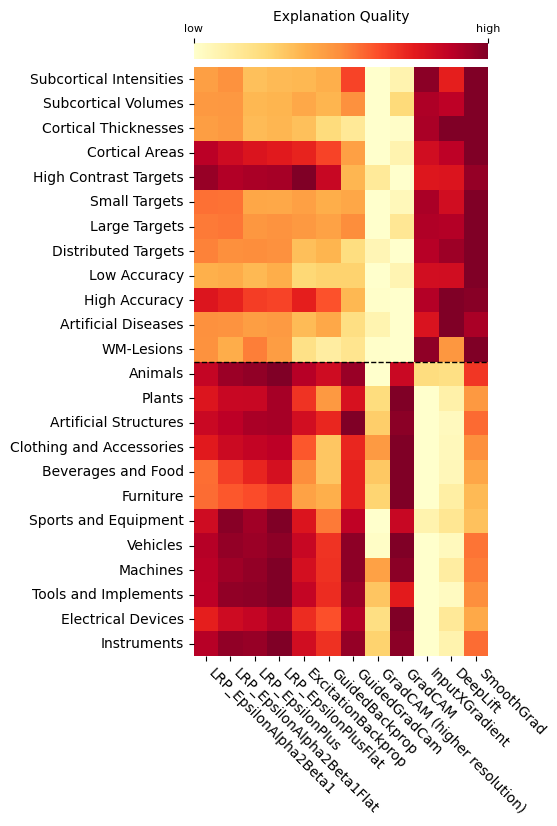

In [51]:
# plot combined heatmap
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[0.02, 0.98], hspace=0.05)

# Define axes
cbar_ax = fig.add_subplot(gs[0])
ax = fig.add_subplot(gs[1])

# Draw heatmap
sns.heatmap(
    combined_df,
    cmap="YlOrRd",
    fmt=".2f",
    square=True,
    ax=ax,
    cbar_ax=cbar_ax,
    cbar_kws={"orientation": "horizontal"}
)

# Resize colorbar to fit the heatmap
pos = ax.get_position()
cbar_ax.set_position([pos.x0, pos.y0 + pos.height + 0.01, pos.width, 0.02])

# Format colorbar
cbar = ax.collections[0].colorbar
vmin, vmax = cbar.vmin, cbar.vmax
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels(['low', 'high'])
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.tick_top()
cbar.set_label('Explanation Quality', labelpad=2, fontsize=10)
cbar.ax.tick_params(labelsize=8)

# Add a horizontal line to separate the heatmap
ax.axhline(y=len(plot_df_), color='black', linestyle='--', linewidth=1)
# Remove x-axis label
ax.set_xlabel('')
# Rotate x-axis tick labels
plt.setp(ax.get_xticklabels(), rotation=-45, ha='left')

plt.show()

fig.savefig("/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/scripts_xai_related/generate_paper_output/plots/heatmap_brain_and_natural_imgs.png", dpi=500, bbox_inches='tight', pad_inches=0)
